<a href="https://colab.research.google.com/github/SampellySuhas/SS/blob/main/BILSTM%5BModel%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BiLSTM MODEL FOR SENTIMENT ANALYSIS
Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training samples: 20000
Testing samples: 25000
Vocabulary size: 10000
Max sequence length: 200

Building BiLSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training model...
------------------------------------------------------------
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 430ms/step - accuracy: 0.7459 - loss: 0.4929 - val_accuracy: 0.8550 - val_loss: 0.3615
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 427ms/step - accuracy: 0.8891 - loss: 0.2824 - val_accuracy: 0.8790 - val_loss: 0.2971
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 440ms/step - accuracy: 0.9226 - loss: 0.2089 - val_accuracy: 0.8673 - val_loss: 0.3213
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 437ms/step - accuracy: 0.9377 - loss: 0.1750 - val_accuracy: 0.8500 - val_loss: 0.4111
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 424ms/step - accuracy: 0.9452 - loss: 0.1540 - val_accuracy: 0.8648 - val_loss: 0.4063
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 422ms/step - accuracy: 0.9551 - loss: 0.1274 - val_accuracy: 0.8580 - val_loss: 0.4560
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 432ms/step - accuracy: 0.9674 - loss: 0.0964 - val_accuracy: 0.8480 - val_loss: 0.4

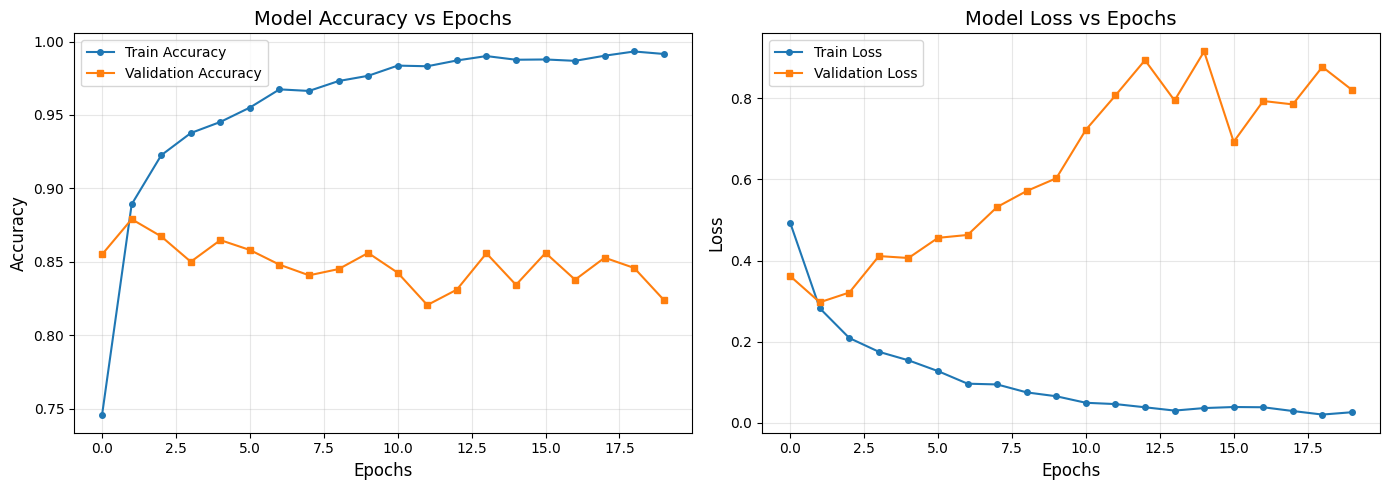

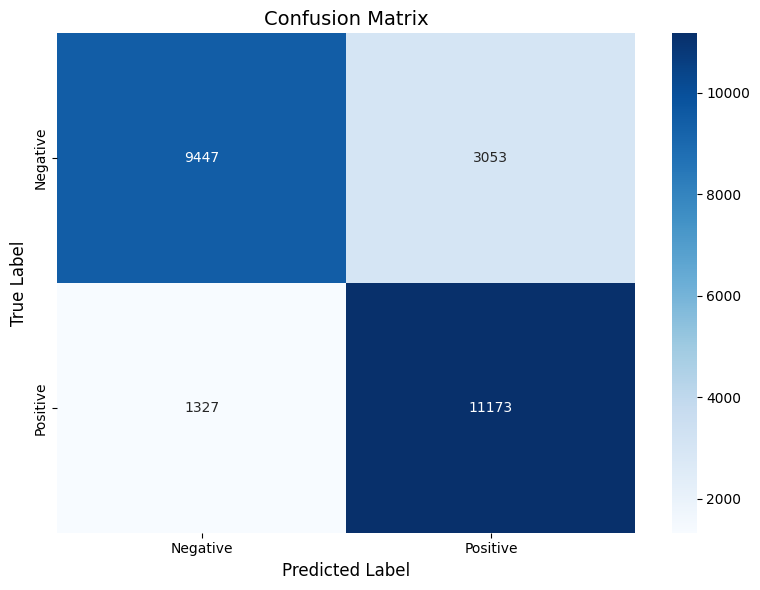


CLASSIFICATION METRICS:
Accuracy:  0.8248 (82.48%)
Precision: 0.7854
Recall:    0.8938
F1-Score:  0.8361


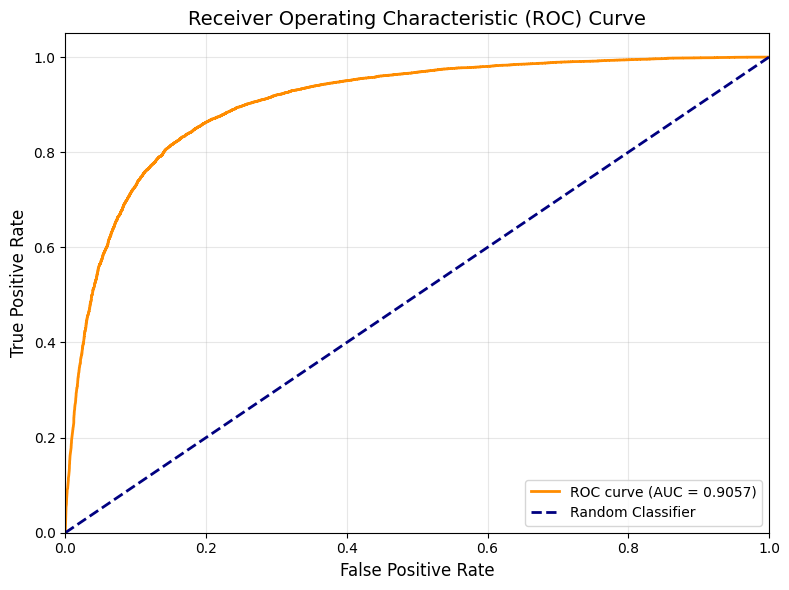


ROC AUC Score: 0.9057

FINAL SUMMARY
✓ Best Validation Accuracy: 0.8790
✓ Final Test Accuracy: 0.8248
✓ ROC AUC Score: 0.9057
✓ Visualizations saved: training_history.png, confusion_matrix.png, roc_curve.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import Callback
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Custom callback to stop when accuracy reaches 90%
class AccuracyThresholdCallback(Callback):
    def __init__(self, threshold=0.90):
        super(AccuracyThresholdCallback, self).__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc and val_acc >= self.threshold:
            print(f"\n✅ Target accuracy {self.threshold*100:.0f}% reached at epoch {epoch+1}!")
            self.model.stop_training = True

# Load and preprocess IMDB dataset
def load_and_preprocess_data():
    # Load IMDB dataset (top 10,000 most frequent words)
    vocab_size = 10000
    max_len = 200

    print("Loading IMDB dataset...")
    (X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

    # Pad sequences to same length
    X_train = sequence.pad_sequences(X_train, maxlen=max_len)
    X_test = sequence.pad_sequences(X_test, maxlen=max_len)

    # Use a subset of training data for faster training
    # Remove this line if you want full dataset
    X_train, y_train = X_train[:20000], y_train[:20000]

    return X_train, X_test, y_train, y_test, vocab_size, max_len

# Build BiLSTM model
def build_bilstm_model(vocab_size, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(64, dropout=0.5, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy vs epochs
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o', markersize=4)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=4)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Model Accuracy vs Epochs', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss vs epochs
    ax2.plot(history.history['loss'], label='Train Loss', marker='o', markersize=4)
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s', markersize=4)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Model Loss vs Epochs', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title('Confusion Matrix', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Print classification metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("\n" + "="*50)
    print("CLASSIFICATION METRICS:")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*50)

# Plot ROC curve
def plot_roc_curve(y_true, y_pred_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
    plt.show()

    return roc_auc

# Main execution
def main():
    print("="*60)
    print("BiLSTM MODEL FOR SENTIMENT ANALYSIS")
    print("="*60)

    # Load and preprocess data
    X_train, X_test, y_train, y_test, vocab_size, max_len = load_and_preprocess_data()

    print(f"\nTraining samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"Vocabulary size: {vocab_size}")
    print(f"Max sequence length: {max_len}")

    # Build model
    print("\nBuilding BiLSTM model...")
    model = build_bilstm_model(vocab_size, max_len)
    model.summary()

    # Train model
    print("\nTraining model...")
    print("-"*60)

    # Custom callback to stop at 90% accuracy
    accuracy_callback = AccuracyThresholdCallback(threshold=0.90)

    history = model.fit(
        X_train, y_train,
        batch_size=64,
        epochs=20,  # Will stop early if 90% accuracy reached
        validation_split=0.2,
        verbose=1,
        callbacks=[accuracy_callback]
    )

    # Evaluate on test set
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

    # Check if accuracy requirement is met
    if test_accuracy >= 0.90:
        print("\n✅ SUCCESS: Model achieved 90%+ accuracy!")
    else:
        print(f"\n⚠️  WARNING: Model achieved {test_accuracy*100:.2f}% accuracy (<90%)")
        print("Consider: increasing epochs, using more data, or adjusting model architecture")

    # Make predictions
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Generate all visualizations
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)

    # 1. Training history (accuracy vs epochs & loss vs epochs)
    plot_training_history(history)

    # 2. Confusion matrix
    plot_confusion_matrix(y_test, y_pred)

    # 3. ROC curve
    roc_auc = plot_roc_curve(y_test, y_pred_prob)
    print(f"\nROC AUC Score: {roc_auc:.4f}")

    # Final summary
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)
    print(f"✓ Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
    print(f"✓ Final Test Accuracy: {test_accuracy:.4f}")
    print(f"✓ ROC AUC Score: {roc_auc:.4f}")
    print(f"✓ Visualizations saved: training_history.png, confusion_matrix.png, roc_curve.png")
    print("="*60)

if __name__ == "__main__":
    main()